(modules-solid-mechanics-crystal-plasticity-slip-anisotropy)=
# Slip anisotropy: specifying the interaction matrix three ways

## What is slip anisotropy?

A crystal deforms plastically by dislocation glide on discrete **slip systems**. As
dislocations multiply they obstruct one another, and a slip system's strength rises
with the dislocation content a moving dislocation must cut through — *forest
hardening*. **Slip anisotropy** is the fact that this obstruction is **directional**:
dislocations on one system do not harden every other system equally. A dislocation
on system $r$ might barely impede a coplanar system yet strongly pin a system it
forms a sessile junction with.

## The latent-hardening matrix

That directionality is carried by an $n_\text{slip}\times n_\text{slip}$
**interaction (latent-hardening) matrix** $h$: the entry $h_{ir}$ is how much the
dislocation density $\rho_r$ on system $r$ contributes to the forest hardening of
system $i$. The diagonal $h_{ii}$ is **self-hardening**; the off-diagonals are
**latent hardening** — system $i$ strengthened by activity on *other* systems. The
forest density seen by system $i$ is the weighted sum $\sum_r h_{ir}\rho_r$, and the
slip strength follows the Taylor relation

$$
\tau_i = \tau_0 + \alpha\mu b\sqrt{\sum_r h_{ir}\,\rho_r}.
$$

With $h=I$ every system hardens only itself (the isotropic, self-hardening
baseline); a non-identity $h$ is what makes hardening anisotropic. Physically the
off-diagonals fall into a few interaction *categories* (self, coplanar, collinear,
glissile junction, Hirth lock, Lomer–Cottrell sessile), so $h$ is built from a
handful of coefficients rather than $n^2$ free numbers.

## How it works in crystal plasticity

In a crystal-plasticity model each material point carries a per-slip state (here a
dislocation density) that evolves as the systems slip. Within a step the stress
gives the resolved shears, the strength map above turns the per-slip state
**through $h$** into per-system strengths $\tau_i$, the slip rule turns resolved
shear and strength into slip rates, and those rates drive the plastic deformation
*and* the lattice reorientation. So $h$ couples all slip systems at a point: activity
on one system raises the strength of the systems it interacts with, changing which
systems slip next — and hence the stress response and the developing texture. The
full derivation, the matrix-construction menu, and an annotated $n\times n$
illustration are on the
[crystal-plasticity module page](modules-solid-mechanics-crystal-plasticity) under
*Latent (slip-system interaction) hardening*.

## This example

The runnable companion below drives the **same** FCC model (with reorientation)
three ways, differing only in how $h$ is supplied, and overlays the macroscopic
stress--strain response and the final texture:

1. **Diagonal ($h=I$)** — pure self-hardening via
   [](models-DislocationObstacleStrengthMap); the baseline, no matrix.
2. **Block** — a few physical coefficients mapped onto $h$ by a slip-family
   partition, via [](tensors-SquareMatrix) `fill = block`.
3. **Dense** — the full matrix given explicitly with `fill = dense`.

In [1]:
import sys

if "google.colab" in sys.modules:
    !pip install -q neml2

## Setup

A batch of randomly-oriented grains deformed under a prescribed uniaxial
deformation-rate history. Each grain integrates its elastic strain, orientation,
and per-slip dislocation density; we read the per-grain Cauchy stress (averaged for
a macroscopic curve) and the final orientations (texture).

In [2]:
import matplotlib.pyplot as plt
import torch

import neml2
import neml2.types
import neml2.texture as texture

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

NGRAINS = 32
NTIME = 50
NSLIP = 12
RATE = 1.0e-3
MAX_STRAIN = 0.1
AXIAL = 2
INIT_RHO = 10.0
END_T = MAX_STRAIN / RATE


def random_orientations(ngrains):
    g = torch.randn(ngrains, 3, 3)
    q, r = torch.linalg.qr(g)
    q = q * torch.sign(torch.diagonal(r, dim1=-2, dim2=-1)).unsqueeze(-2)
    q[:, :, 0] = q[:, :, 0] * torch.linalg.det(q).unsqueeze(-1)
    return neml2.types.MRP.from_matrix(neml2.types.R2(q, 1))


orientations = random_orientations(NGRAINS)
strain = torch.linspace(0.0, MAX_STRAIN, NTIME)

## Three interaction matrices

The three variants differ **only** in the strength leaf (and, for the latter two,
an `hmat` tensor). Everything else — geometry, slip rule, dislocation-density
evolution, integrators, solve — is shared.

- `fill = block` with `blocks = '3 3 3 3'` treats the 12 slip systems as four
  families of three and sets one coefficient per family pair: `1.0` on the diagonal
  (self) and `0.4` off-diagonal (latent).
- `fill = dense` gives the full $12\times12$ matrix, here $I + 0.2\,(J-I)$,
  generated in Python to keep the cell readable.

In [3]:
DIAG_STRENGTH = """  [slip_strength]
    type = DislocationObstacleStrengthMap
    dislocation_density = 'dislocation_density'
    alpha = 0.3
    mu = 1.0e5
    b = 1.0e-4
    constant_strength = 50.0
  []"""

BLOCK_HMAT = """  [hmat]
    type = SquareMatrix
    fill = block
    blocks = '3 3 3 3'
    data = '1.0 0.4 0.4 0.4  0.4 1.0 0.4 0.4  0.4 0.4 1.0 0.4  0.4 0.4 0.4 1.0'
  []"""

_dense = (torch.eye(NSLIP) + 0.2 * (1.0 - torch.eye(NSLIP))).flatten().tolist()
_dense_str = " ".join(repr(round(v, 3)) for v in _dense)
DENSE_HMAT = f"""  [hmat]
    type = SquareMatrix
    m = 12
    fill = dense
    data = '{_dense_str}'
  []"""

INTERACTION_STRENGTH = """  [slip_strength]
    type = DislocationInteractionStrengthMap
    dislocation_density = 'dislocation_density'
    interaction_matrix = 'hmat'
    alpha = 0.3
    mu = 1.0e5
    b = 1.0e-4
    constant_strength = 50.0
  []"""

## Build and run the three models

Each variant is written to its own input file and driven by a `TransientDriver`.

In [4]:
ori_literal = repr(orientations.data.detach().cpu().tolist())


def build_model(variant):
    if variant == "diagonal":
        hmat_block, strength = "", DIAG_STRENGTH
    elif variant == "block":
        hmat_block, strength = BLOCK_HMAT + "\n", INTERACTION_STRENGTH
    else:
        hmat_block, strength = DENSE_HMAT + "\n", INTERACTION_STRENGTH
    return f"""
[Tensors]
  [sdirs]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 0], dtype=torch.int64))'
  []
  [splanes]
    type = Python
    expr = 'MillerIndex(torch.tensor([1, 1, 1], dtype=torch.int64))'
  []
{hmat_block}  [times]
    type = Python
    expr = 'Scalar(torch.linspace(0.0, {END_T}, {NTIME}, dtype=torch.float64).reshape({NTIME}, 1))'
  []
  [drate]
    type = Python
    expr = 'SR2.fill({-RATE / 2}, {-RATE / 2}, {RATE}, 0, 0, 0).dynamic_batch.expand({NTIME}, {NGRAINS})'
  []
  [vort]
    type = Python
    expr = 'WR2(torch.zeros({NTIME}, {NGRAINS}, 3, dtype=torch.float64))'
  []
  [ic_ori]
    type = Python
    expr = 'MRP(torch.tensor({ori_literal}, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [ic_es]
    type = Python
    expr = 'SR2(torch.zeros({NGRAINS}, 6, dtype=torch.float64), sub_batch_ndim=1).sub_batch.retag(1)'
  []
  [ic_rho]
    type = Python
    expr = 'Scalar(torch.full(({NGRAINS}, {NSLIP}), {INIT_RHO}, dtype=torch.float64), sub_batch_ndim=2).sub_batch.retag(2)'
  []
[]

[Data]
  [crystal_geometry]
    type = CubicCrystal
    lattice_parameter = 1
    slip_directions = 'sdirs'
    slip_planes = 'splanes'
  []
[]

[Drivers]
  [driver]
    type = TransientDriver
    model = 'model'
    prescribed_time = 'times'
    prescribed_SR2_names = 'deformation_rate'
    prescribed_SR2_values = 'drate'
    prescribed_WR2_names = 'vorticity'
    prescribed_WR2_values = 'vort'
    ic_MRP_names = 'orientation'
    ic_MRP_values = 'ic_ori'
    ic_SR2_names = 'elastic_strain'
    ic_SR2_values = 'ic_es'
    ic_Scalar_names = 'dislocation_density'
    ic_Scalar_values = 'ic_rho'
  []
[]

[Models]
  [euler_rodrigues]
    type = RotationMatrix
    from = 'orientation'
    to = 'orientation_matrix'
  []
  [elasticity]
    type = LinearIsotropicElasticity
    coefficients = '1e5 0.25'
    coefficient_types = 'YOUNGS_MODULUS POISSONS_RATIO'
    strain = 'elastic_strain'
    stress = 'cauchy_stress'
  []
  [resolved_shear]
    type = ResolvedShear
    stress = 'cauchy_stress'
  []
  [elastic_stretch]
    type = ElasticStrainRate
  []
  [plastic_spin]
    type = PlasticVorticity
  []
  [plastic_deformation_rate]
    type = PlasticDeformationRate
  []
  [orientation_rate]
    type = OrientationRate
  []
  [slip_rule]
    type = PowerLawSlipRule
    n = 8.0
    gamma0 = 2.0e-1
  []
{strength}
  [dislocation_density_rate]
    type = PerSlipForestDislocationEvolution
    dislocation_density = 'dislocation_density'
    k1 = 1e2
    k2 = 40.0
  []
  [integrate_dislocation_density]
    type = ScalarBackwardEulerTimeIntegration
    variable = 'dislocation_density'
  []
  [integrate_elastic_strain]
    type = SR2BackwardEulerTimeIntegration
    variable = 'elastic_strain'
  []
  [integrate_orientation]
    type = WR2ImplicitExponentialTimeIntegration
    variable = 'orientation'
  []
  [implicit_rate]
    type = ComposedModel
    models = 'euler_rodrigues elasticity orientation_rate resolved_shear
              elastic_stretch plastic_deformation_rate plastic_spin
              slip_rule slip_strength dislocation_density_rate
              integrate_dislocation_density integrate_elastic_strain integrate_orientation'
  []
[]

[EquationSystems]
  [es]
    type = NonlinearSystem
    model = 'implicit_rate'
    unknowns = 'elastic_strain orientation dislocation_density'
    residuals = 'elastic_strain_residual orientation_residual dislocation_density_residual'
  []
[]

[Solvers]
  [newton]
    type = NewtonWithLineSearch
    max_linesearch_iterations = 5
    linear_solver = 'lu'
  []
  [lu]
    type = DenseLU
  []
[]

[Models]
  [cp_warmup_1]
    type = CrystalPlasticityStrainPredictor
    scale = 0.1
  []
  [cp_warmup_2]
    type = ConstantExtrapolationPredictor
    unknowns_MRP = 'orientation'
    unknowns_Scalar = 'dislocation_density'
  []
  [predictor]
    type = ComposedModel
    models = 'cp_warmup_1 cp_warmup_2'
  []
  [update]
    type = ImplicitUpdate
    equation_system = 'es'
    solver = 'newton'
    predictor = 'predictor'
  []
  [model]
    type = ComposedModel
    models = 'update elasticity'
    additional_outputs = 'elastic_strain cauchy_stress'
  []
[]
"""


results = {}
for variant in ["diagonal", "block", "dense"]:
    path = f"model_{variant}.i"
    with open(path, "w") as fh:
        fh.write(build_model(variant))
    driver = neml2.load_input(path).get_driver("driver")
    driver.run()
    res = driver.result()
    nsteps = driver.nsteps
    macro = [0.0] + [
        float(res[f"output.{i}.cauchy_stress"].reshape(-1, 6)[:, AXIAL].mean())
        for i in range(1, nsteps)
    ]
    final_ori = neml2.types.MRP(res[f"output.{nsteps - 1}.orientation"].reshape(-1, 3).detach())
    results[variant] = (torch.tensor(macro), final_ori)
    print(f"{variant:9s}: peak macro axial stress = {max(macro):.2f} MPa")

/home/tranh/miniconda3/envs/moose-src/lib/python3.13/site-packages/torch/utils/_device.py:122: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  return func(*args, **kwargs)


diagonal : peak macro axial stress = 57.18 MPa


block    : peak macro axial stress = 71.49 MPa


dense    : peak macro axial stress = 64.39 MPa


## Macroscopic stress--strain

Latent hardening raises the aggregate flow stress relative to pure self-hardening:
a dislocation on one system now also hardens the others.

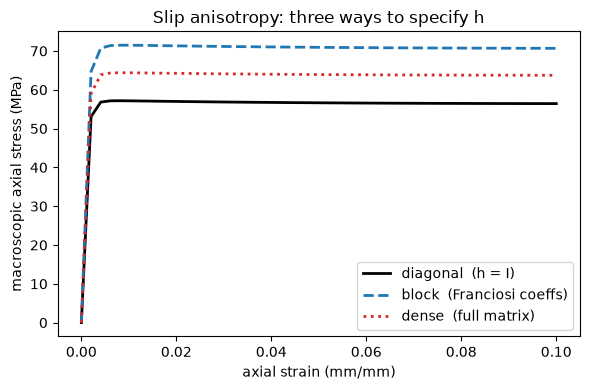

In [5]:
s = strain.detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 4))
styles = {
    "diagonal": ("k-", "diagonal  (h = I)"),
    "block": ("C0--", "block  (Franciosi coeffs)"),
    "dense": ("C3:", "dense  (full matrix)"),
}
for variant, (style, label) in styles.items():
    ax.plot(s, results[variant][0].detach().cpu().numpy(), style, lw=2, label=label)
ax.set_xlabel("axial strain (mm/mm)")
ax.set_ylabel("macroscopic axial stress (MPa)")
ax.set_title("Slip anisotropy: three ways to specify h")
ax.legend()
fig.tight_layout()

## Final texture

The three runs develop **nearly the same** deformation texture (inverse pole figures
along the loading direction) — which is expected and correct. Lattice reorientation is
governed by *which* slip systems carry the deformation (the slip geometry and resolved
shears), and that is common to all three runs. The interaction matrix changes each
system's hardening *magnitude*, not the slip directions, so it barely shifts the texture
at this strain; the discriminating observable here is the **stress--strain curve above**.
This is also why calibrating $h$ from texture alone is ill-posed — see the identifiability
note on the [crystal-plasticity module page](modules-solid-mechanics-crystal-plasticity).

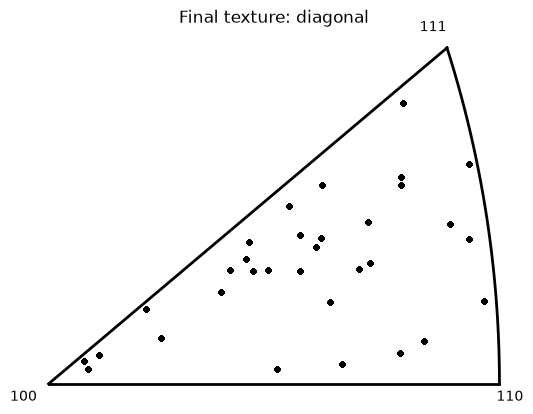

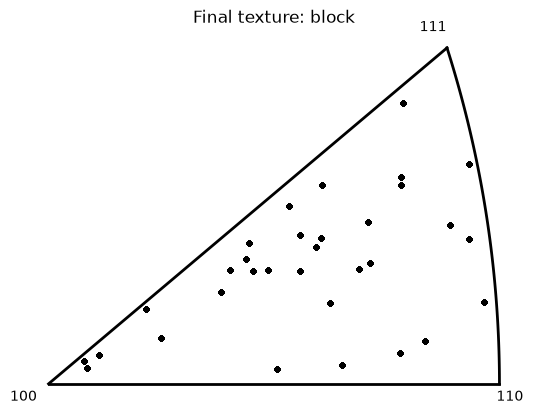

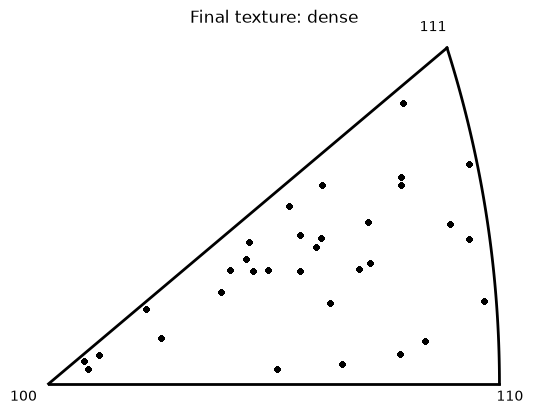

In [6]:
loading = torch.tensor([0.0, 0.0, 1.0], device=device)
for variant in ["diagonal", "block", "dense"]:
    texture.pretty_plot_inverse_pole_figure(results[variant][1], loading, crystal_symmetry="432")
    plt.title(f"Final texture: {variant}")

## See also

- [](modules-solid-mechanics-crystal-plasticity) — the crystal-plasticity module page:
  the latent-hardening theory, the matrix-construction menu, and the annotated
  $n_\text{slip}\times n_\text{slip}$ illustration.
- Models: [](models-DislocationObstacleStrengthMap) (the diagonal baseline used here),
  [](models-DislocationInteractionStrengthMap), [](models-LinearInteractionStrengthMap),
  and [](models-LinearInteractionHardeningRule); plus [](tensors-SquareMatrix), the
  matrix builder.
- [Slip-anisotropy calibration](tutorials-optimization-taylor-polycrystal) — recover the
  latent-hardening ratio from synthetic stress + per-step texture through the pyzag adjoint.